In [1]:
import math
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchinfo
import torch.nn.functional as F
from torch.utils.data import DataLoader, IterableDataset
import matplotlib.pyplot as plt
import time
import os
import glob

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Synthetic dataset preparation and visualization

##### Helper functions for colors and noise generation

In [3]:
def get_random_color() -> list[int]:
    return np.random.randint(10, 245, size=3).tolist()

def check_contrast(background, foreground) -> list[int]:
    min_contrast = np.random.randint(40, 120)
    while abs(np.mean(background) - np.mean(foreground)) < min_contrast:
        foreground = get_random_color()
    return foreground


def add_gauss_noise(image) -> np.ndarray:
    noise = np.random.normal(0, 10, image.shape).astype(np.float32)
    image = np.clip(image.astype(np.float32) + noise, 0, 255)
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    return blurred.astype(np.uint8)


def is_far_enough(point, existing_points, distance) -> bool:
    for x, y in existing_points:
        dx = point[0] - x
        dy = point[1] - y

        if (dx ** 2 + dy ** 2) < distance ** 2:
            return False

    return True

##### Generating simple shapes
Triangle - 3 random points cv2.fillPoly()

Quadrilateral - 4 random points and call cv2.fillPoly()

Star - 1 random point in the center and 5 random outer points (use a min distance)

In [4]:
def get_triangle_points(width, height, distance) -> list[list[int]]:
    triangle_points = []

    while len(triangle_points) < 3:
        x = np.random.randint(10, width - 10)
        y = np.random.randint(10, height - 10)

        if is_far_enough([x, y], triangle_points, distance):
            triangle_points.append([x, y])

    return triangle_points


def get_quadrilateral_points(width, height, distance) -> list[list[int]]:
    quadrilateral_points = []

    while len(quadrilateral_points) < 4:
        x = np.random.randint(5, width - 5)
        y = np.random.randint(5, height - 5)
        if is_far_enough([x, y], quadrilateral_points, distance):
            quadrilateral_points.append([x, y])

    center_x = sum(p[0] for p in quadrilateral_points) / 4
    center_y = sum(p[1] for p in quadrilateral_points) / 4
    quadrilateral_points.sort(key=lambda p: math.atan2(p[1] - center_y, p[0] - center_x))

    return quadrilateral_points


def get_star_points(width, height, distance) -> list[list[int]]:
    center_x = np.random.randint(width // 4, 3 * width // 4)
    center_y = np.random.randint(height // 4, 3 * height // 4)

    star_points = [[center_x, center_y]]
    radius = min(width, height) // 4   # 32 px for 128x128

    while len(star_points) < 6:
        x = center_x + np.random.randint(-radius, radius)
        y = center_y + np.random.randint(-radius, radius)
        x = max(5, min(x, width - 5))
        y = max(5, min(y, height - 5))
        if is_far_enough([x, y], star_points, distance):
            star_points.append([x, y])
    return star_points

##### Generate complex shapes
Checkerboard - 3x4 grid where each cell is different color from the cell that is sticked to. Keypoints are all the corner's intersections (where different colors meet)

3D cube - pick 1 center point, 3 inner points that are connected to the center(star) and 3 outter points that are edges and connecting to inner points. Then draw 3 quatrilaterals to make it look like 3D cude

In [5]:
def get_checkerboard_points(image, width, height, rows=3, cols=4) -> tuple[list[list[int]], tuple[int, int, int, int]]:
    checkerboard_w = np.random.randint(50, 90)
    checkerboard_h = np.random.randint(40, 80)

    x0 = np.random.randint(10, width - checkerboard_w - 10)
    y0 = np.random.randint(10, height - checkerboard_h - 10)

    cell_w = checkerboard_w // cols
    cell_h = checkerboard_h // rows

    colors = [get_random_color(), None]
    colors[1] = check_contrast(colors[0], get_random_color())

    # grid corners 4 x 5 = 20 keypoints
    checkerboard_points = []
    for row in range(rows + 1):
        for col in range(cols + 1):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            checkerboard_points.append([x, y])

    # fill cells
    for row in range(rows):
        for col in range(cols):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            cv2.rectangle(image, (x, y), (x + cell_w, y + cell_h), colors[(row + col) % 2], -1)

    return checkerboard_points, (x0, y0, checkerboard_w, checkerboard_h)


def get_3d_cube(image, width, height) -> list[list[int]]:
    center_x = np.random.randint(width // 4, 3 * width // 4)
    center_y = np.random.randint(height // 4, 3 * height // 4)
    base_angle = np.random.uniform(0, 2 * np.pi)

    inner_points = []
    for step in range(3):
        angle = base_angle + step * (2 * np.pi / 3) # 120
        distance = np.random.randint(12, 25)
        x = int(np.clip(center_x + distance * np.cos(angle), 5, width - 5))
        y = int(np.clip(center_y + distance * np.sin(angle), 5, height - 5))
        inner_points.append([x, y])

    outer_points = []
    for i in range(3):
        point_a = inner_points[i]
        point_b = inner_points[(i + 1) % 3]
        mid_x = (point_a[0] + point_b[0]) / 2
        mid_y = (point_a[1] + point_b[1]) / 2
        push_factor = np.random.uniform(1.2, 1.8)  # depth
        outer_x = int(np.clip(center_x + (mid_x - center_x) * push_factor, 5, width - 5))
        outer_y = int(np.clip(center_y + (mid_y - center_y) * push_factor, 5, height - 5))
        outer_points.append([outer_x, outer_y])

    center = [center_x, center_y]
    I1, I2, I3 = inner_points
    O12, O23, O31 = outer_points

    faces = [[center, I1, O12, I2], [center, I2, O23, I3], [center, I3, O31, I1]]
    for face in faces:
        arr = np.array(face, np.int32)
        cv2.fillPoly(image, [arr], get_random_color())
        cv2.polylines(image, [arr], True, (0, 0, 0), 2)

    return [center] + inner_points + outer_points

##### Generate images

In [6]:
def generate_image_with_shape(shape, width, height) -> tuple[np.ndarray, list[list[int]]]:
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)
    foreground = check_contrast(background, get_random_color())

    if shape == 'triangle':
        keypoints = get_triangle_points(width, height, 10)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)
    elif shape == 'quadrilateral':
        keypoints = get_quadrilateral_points(width, height, 10)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)
    elif shape == 'star':
        keypoints = get_star_points(width, height, 10)
        for point in keypoints[1:]:  # lines center to outer point
            cv2.line(image, tuple(map(int, keypoints[0])), tuple(map(int, point)), foreground, 2)
    elif shape == 'chessboard':
        keypoints, box = get_checkerboard_points(image, width, height)
    elif shape == 'cube':
        keypoints = get_3d_cube(image, width, height)
    else:
        raise ValueError(shape)

    return add_gauss_noise(image), keypoints


def generate_image_with_more_shapes(width, height, num_shapes) -> tuple[np.ndarray, list[list[int]]]:
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)
    occupied_part = np.zeros((height, width), np.uint8)
    keypoints_in_image = []

    for _ in range(num_shapes):
        for _ in range(20):
            shape_type = np.random.choice(['triangle', 'quadrilateral', 'star'])

            if shape_type == 'triangle':
                points = get_triangle_points(width, height, distance=20)
            elif shape_type == 'quadrilateral':
                points = get_quadrilateral_points(width, height, distance=20)
            else:
                points = get_star_points(width, height, distance=20)

            temp_mask = np.zeros_like(occupied_part)
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(temp_mask, tuple(map(int, points[0])), tuple(map(int, point)), 255, 3)#
            else:
                cv2.fillPoly(temp_mask, [np.array(points, np.int32)], 255)

            if np.any(occupied_part & temp_mask):
                continue  # overlaps

            # no overlap draw it
            color = check_contrast(background, get_random_color())
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(image, tuple(map(int, points[0])), tuple(map(int, point)), color, 2)
            else:
                cv2.fillPoly(image, [np.array(points, np.int32)], color)

            occupied_part |= temp_mask
            keypoints_in_image.extend(points)
            break

    return add_gauss_noise(image), keypoints_in_image


##### Homography augmentation
This should happen during data generation and durng homographic adaptation

In [7]:
def generate_random_homography(width, height, min_distance=20) -> np.ndarray:
    center_x = width // 2
    center_y = height // 2

    quadrants = [
        (10, center_x - min_distance, 10, center_y - min_distance),  # tl
        (center_x + min_distance, width - 10, 10, center_y - min_distance),  # tr
        (center_x +min_distance , width - 10, center_y + min_distance, height - 10),  # br
        (10, center_x - min_distance, center_y + min_distance, height - 10),  # bl
    ]

    original_points = []
    for x_min, x_max, y_min, y_max in quadrants:
        while True:
            x = np.random.randint(x_min, x_max)
            y = np.random.randint(y_min, y_max)
            if is_far_enough([x, y], [[center_x, center_y]], min_distance):
                original_points.append([x, y])
                break

    # 0, 90, 180, 270
    rotated_points = np.roll(original_points, shift=np.random.randint(0, 4), axis=0)

    original = np.array(rotated_points, np.float32)
    transformed = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], np.float32)  # image angles

    return cv2.getPerspectiveTransform(original, transformed)


def apply_homography(image, keypoints, width,height):
    homography = generate_random_homography(width, height)

    warped_image = cv2.warpPerspective(image, homography, (width, height))

    warped_keypoints = []
    for x, y in keypoints:
        homogeneous_point = np.array([x, y, 1], dtype=np.float32)
        transformed = homography @ homogeneous_point
        new_x = transformed[0] / transformed[2]
        new_y = transformed[1] / transformed[2]

        # points inside the image
        if 0 <= new_x < width and 0 <= new_y < height:
            warped_keypoints.append([int(new_x), int(new_y)])

    return warped_image, warped_keypoints


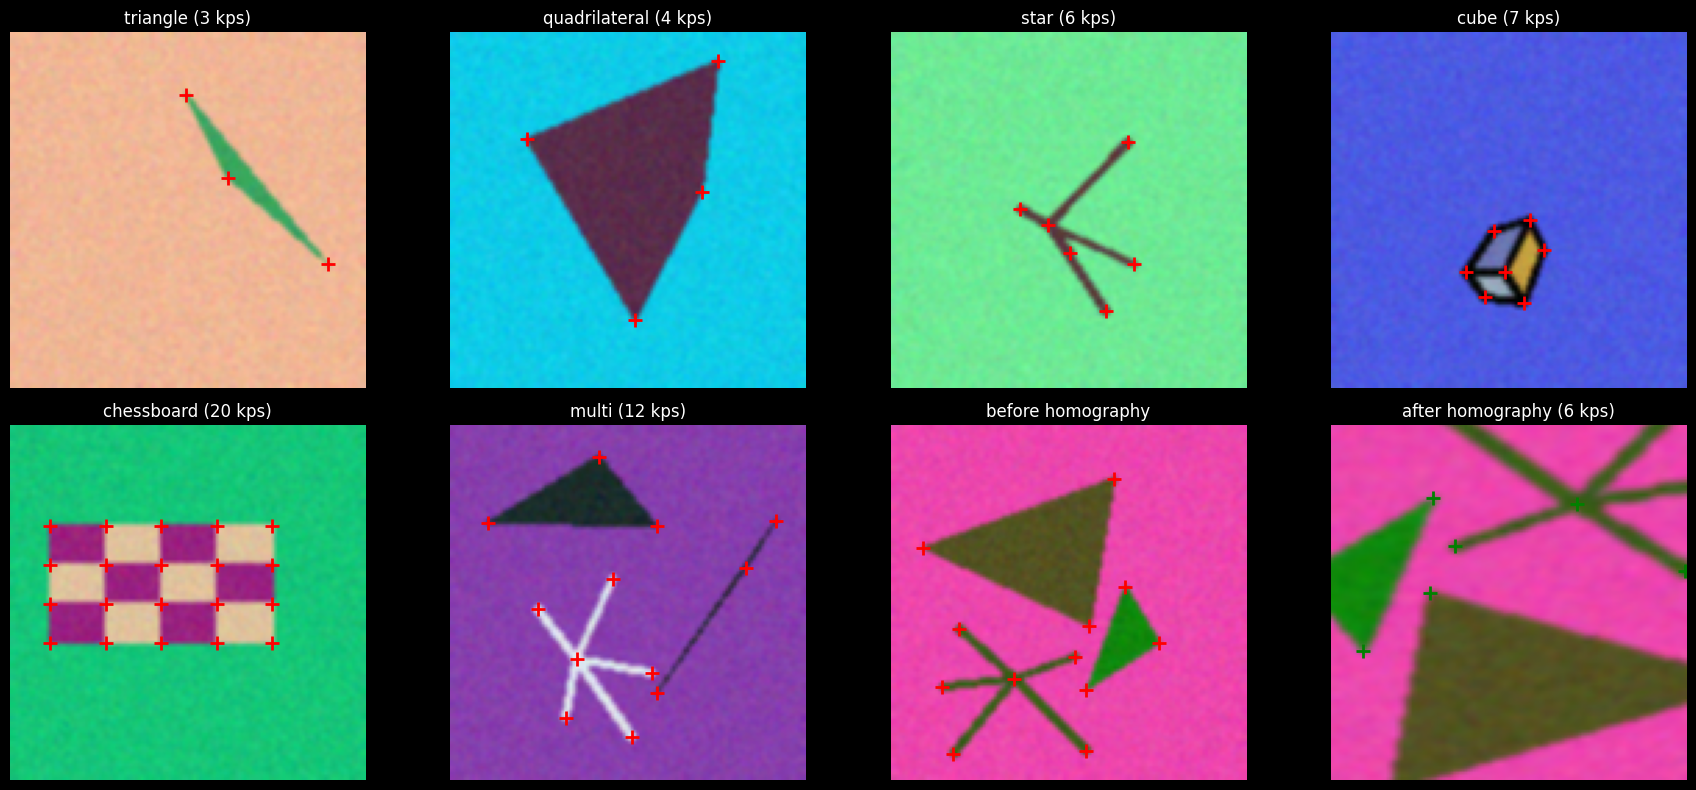

In [119]:
def show_sample_grid():
    IMG_W, IMG_H = 128, 128
    fig, axs = plt.subplots(2, 4, figsize=(18, 8))

    for ax, s in zip(axs[0], ['triangle', 'quadrilateral', 'star', 'cube']):
        image, keypoints = generate_image_with_shape(s, IMG_W, IMG_H)
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        for x, y in keypoints:
            ax.plot(x, y, 'r+', ms=10, mew=2)
        ax.set_title(f'{s} ({len(keypoints)} kps)')
        ax.axis('off')

    image, keypoints = generate_image_with_shape('chessboard', IMG_W, IMG_H)
    axs[1, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 0].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 0].set_title(f'chessboard ({len(keypoints)} kps)')
    axs[1, 0].axis('off')

    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    axs[1, 1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 1].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 1].set_title(f'multi ({len(keypoints)} kps)')
    axs[1, 1].axis('off')

    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    img2, kps2 = apply_homography(image, keypoints, IMG_W, IMG_H)
    axs[1, 2].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 2].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 2].set_title('before homography')
    axs[1, 2].axis('off')

    axs[1, 3].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    for x, y in kps2:
        axs[1, 3].plot(x, y, 'g+', ms=10, mew=2)
    axs[1, 3].set_title(f'after homography ({len(kps2)} kps)')
    axs[1, 3].axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid()


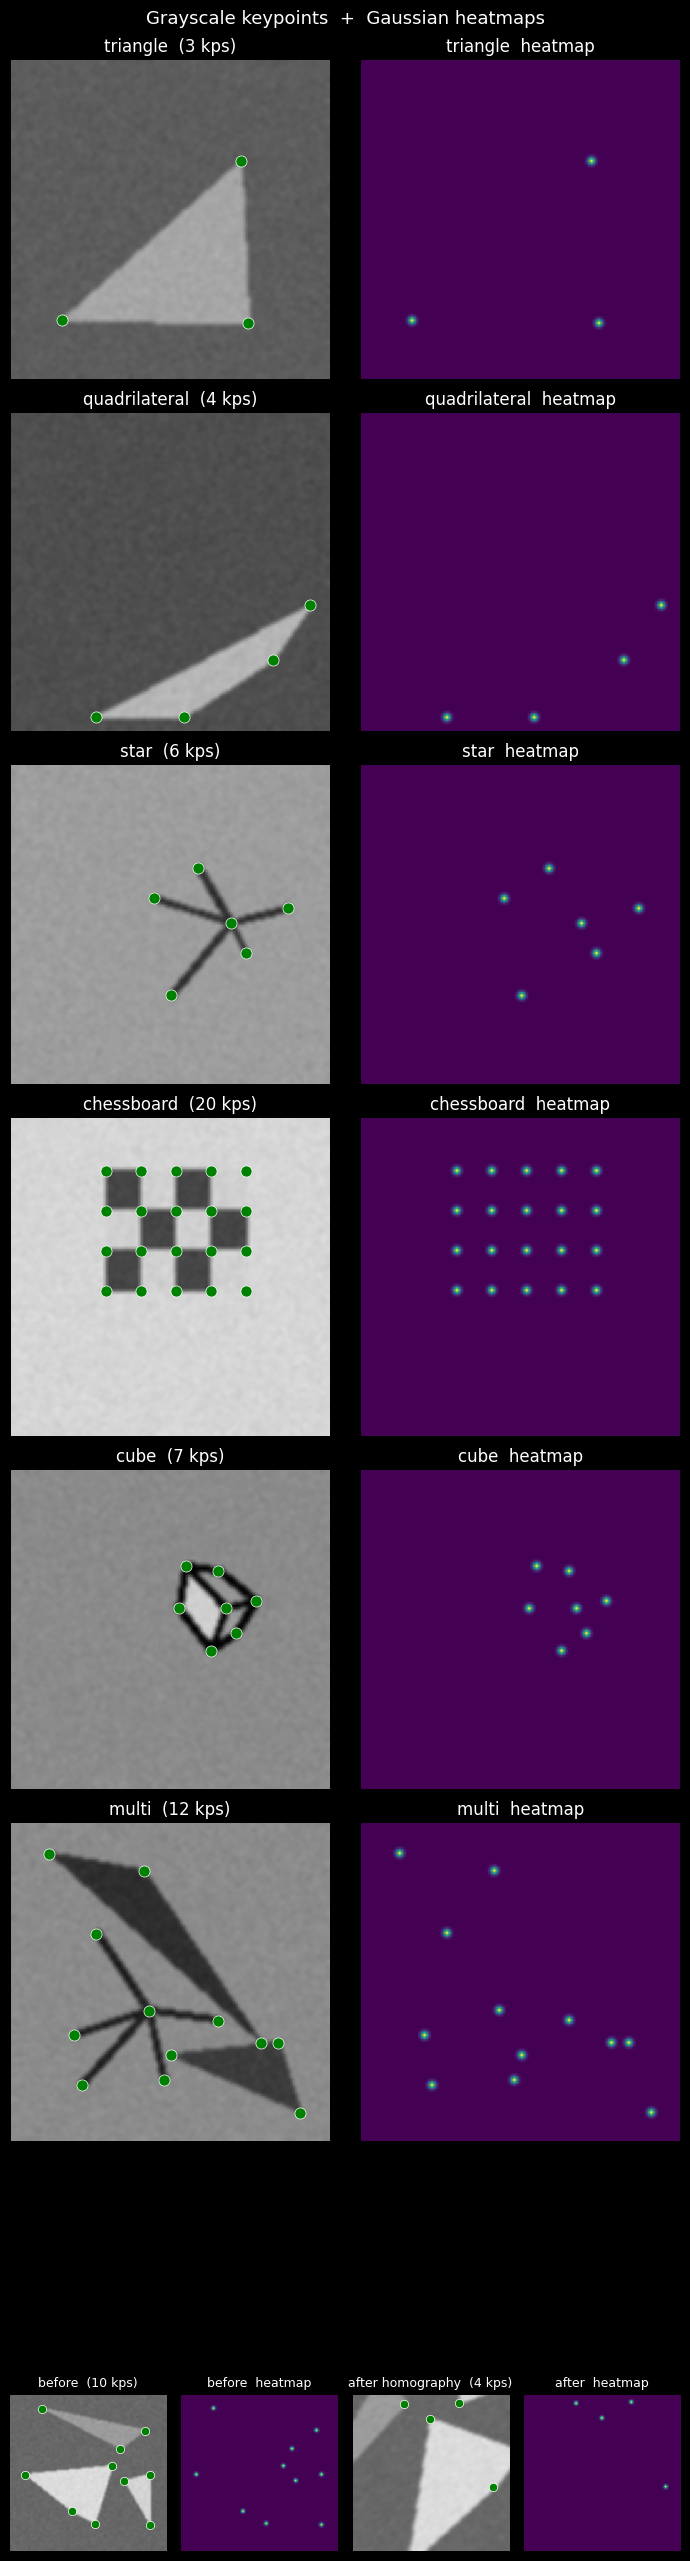

In [120]:
def show_grayscale_heatmap_grid(sigma=1):
    IMG_W, IMG_H = 128, 128

    def make_heatmap(keypoints, width, height):
        if not keypoints:
            return np.zeros((height, width), dtype=np.float32)
        heatmap = np.zeros((height, width), dtype=np.float32)
        xs = np.arange(width)
        ys = np.arange(height)
        xx, yy = np.meshgrid(xs, ys)
        for x, y in keypoints:
            heatmap += np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
        if heatmap.max() > 0:
            heatmap /= heatmap.max()
        return heatmap

    def plot_pair(ax_gray, ax_heat, image, keypoints, gray_title, heat_title, kp_color='g'):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        heatmap = make_heatmap(keypoints, IMG_W, IMG_H)

        ax_gray.imshow(gray, cmap='gray', vmin=0, vmax=255)
        for x, y in keypoints:
            ax_gray.plot(x, y, f'{kp_color}o', ms=8, markerfacecolor=f'{kp_color}',
                         markeredgecolor='white', markeredgewidth=0.5)
        ax_gray.set_title(gray_title)
        ax_gray.axis('off')

        ax_heat.imshow(heatmap, cmap='viridis', vmin=0, vmax=1)
        ax_heat.set_title(heat_title)
        ax_heat.axis('off')

    shapes = ['triangle', 'quadrilateral', 'star', 'chessboard', 'cube']
    num_rows = len(shapes) + 2

    fig, axs = plt.subplots(num_rows, 2, figsize=(7, 3.8 * num_rows))

    # single shapes
    for row, shape in enumerate(shapes):
        image, keypoints = generate_image_with_shape(shape, IMG_W, IMG_H)
        plot_pair(
            axs[row, 0], axs[row, 1],
            image, keypoints,
            gray_title=f'{shape}  ({len(keypoints)} kps)',
            heat_title=f'{shape}  heatmap',
        )

    # multi shapes
    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    plot_pair(
        axs[len(shapes), 0], axs[len(shapes), 1],
        image, keypoints,
        gray_title=f'multi  ({len(keypoints)} kps)',
        heat_title='multi  heatmap',
    )

    # Homography pair
    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    img_w, kps_w = apply_homography(image, keypoints, IMG_W, IMG_H)

    last = len(shapes) + 1
    gray_before = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_after  = cv2.cvtColor(img_w, cv2.COLOR_BGR2GRAY)
    heat_before = make_heatmap(keypoints, IMG_W, IMG_H)
    heat_after  = make_heatmap(kps_w,     IMG_W, IMG_H)

    for ax in [axs[last, 0], axs[last, 1]]:
        ax.remove()

    subfig = fig.add_subfigure(axs[0, 0].get_gridspec()[last, :])
    sub_axs = subfig.subplots(1, 4)

    # Before homography
    sub_axs[0].imshow(gray_before, cmap='gray', vmin=0, vmax=255)
    for x, y in keypoints:
        sub_axs[0].plot(x, y, 'go', ms=6, markerfacecolor='g',
                        markeredgecolor='white', markeredgewidth=0.5)
    sub_axs[0].set_title(f'before  ({len(keypoints)} kps)', fontsize=9)
    sub_axs[0].axis('off')

    sub_axs[1].imshow(heat_before, cmap='viridis', vmin=0, vmax=1)
    sub_axs[1].set_title('before  heatmap', fontsize=9)
    sub_axs[1].axis('off')

    # After homography
    sub_axs[2].imshow(gray_after, cmap='gray', vmin=0, vmax=255)
    for x, y in kps_w:
        sub_axs[2].plot(x, y, 'go', ms=6, markerfacecolor='g',
                        markeredgecolor='white', markeredgewidth=0.5)
    sub_axs[2].set_title(f'after homography  ({len(kps_w)} kps)', fontsize=9)
    sub_axs[2].axis('off')

    sub_axs[3].imshow(heat_after, cmap='viridis', vmin=0, vmax=1)
    sub_axs[3].set_title('after  heatmap', fontsize=9)
    sub_axs[3].axis('off')

    plt.suptitle('Grayscale keypoints  +  Gaussian heatmaps', fontsize=13, y=1.001)
    plt.tight_layout()
    plt.show()

show_grayscale_heatmap_grid()

#### Neural Network
Building neurla network that has encoder and decoder

##### ResNet block
ResNet block is built from Conv - BatchNorm - ReLu - Conv - BatchNorm - ReLu. Its key idea is the skip connection (residual connection), where the input is added to the output of the block.
If the number of input and output channels is different, a 1﷿﷿﷿﷿﷿﷿1 convolution is used to match dimensions before the addition.
This skip connection helps prevent vanishing gradients and makes training deep networks more stable. The skip connection preserves the original signal and improves gradient flow, making it easier for the network to learn useful transformations.

In [8]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.convolution1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm1 = nn.BatchNorm2d(out_channels)
        self.convolution2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.identity = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1)
        else:
            self.identity = nn.Identity()

    def forward(self, x):
        identity = self.identity(x)
        out = self.convolution1(x)
        out = self.batchNorm1(out)
        out = self.relu(out)
        out = self.convolution2(out)
        out = self.batchNorm2(out)
        out += identity
        out = self.relu(out)

        return out

##### Encoder
The encoder is built from 3x(ResNet block -> MaxPoll) and at the end 2xResNet block.

The output from the encoder for a 128x128 image is 16 x 16 x 128. Each pixel in this 16x16 output coresponds to an 8x8 region in the original image (128/16 = 8 and 128/16 = 8) and each of these 128 values decribes everything the newtwork saw in that 8x8 patch of the original images. Then the decoder uses these vectors to decide if there was a keypoint in this 8x8 cell and if yes where?

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential( # input [B 1 128 128] grayscale
            ResNetBlock(1, 64),
            ResNetBlock(64, 64), # B 64 H W
            nn.MaxPool2d(2), # B 64 H/2 W/2

            ResNetBlock(64, 64), # B 64 H/2 W/2
            ResNetBlock(64, 64), # B 64 H/2 W/2
            nn.MaxPool2d(2), # B 64 H/4 W/4

            ResNetBlock(64, 128), # B 128 H/4 W/4
            ResNetBlock(128, 128), # B 128 H/4 W/4
            nn.MaxPool2d(2), # B 128 H/8 W/8

            ResNetBlock(128, 128), # B 128 H/8 W/8
            ResNetBlock(128, 128), # B 128 H/8 W/8
        )

    def forward(self, x):
        return self.body(x) # B 128 H/8 W/8

##### Decoder
The decoder is built from Conv(128 -> 256), BatchNorm, ReLu and Conv(256 -> 65)

The output of the decoder is (B, 65, H/8, W/8) logits, used for training.  The 65 are 64 possible positions withing the 8x8  cells and  +1 cell with no keypoint

In [10]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential( # input [B 128 H/8 W/8]
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False), # [B 256 H/8 W/8]
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 65, kernel_size=1), # [B 65 H/8 W/8]
        )

    def forward(self, x):
        return self.body(x)

##### SuperPoint detector
The model will return logits that will be used to train, then when using the model the output from the model should be set  under softmax, the last channel (65th) should be dropped  and the 64 channels should be rearranged, to get full HxW heatmap

In [11]:
class SuperPointDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x  # (B, 65, H/8, W/8)

In [12]:
model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

print(torchinfo.summary(model, [1, 1, 128, 128], device=device,
                        depth=4,
                        col_names=("input_size", "output_size", "num_params", "mult_adds"),
                        ))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
SuperPointDetector                       [1, 1, 128, 128]          [1, 65, 16, 16]           --                        --
├─Encoder: 1-1                           [1, 1, 128, 128]          [1, 128, 16, 16]          --                        --
│    └─Sequential: 2-1                   [1, 1, 128, 128]          [1, 128, 16, 16]          --                        --
│    │    └─ResNetBlock: 3-1             [1, 1, 128, 128]          [1, 64, 128, 128]         --                        --
│    │    │    └─Conv2d: 4-1             [1, 1, 128, 128]          [1, 64, 128, 128]         128                       2,097,152
│    │    │    └─Conv2d: 4-2             [1, 1, 128, 128]          [1, 64, 128, 128]         576                       9,437,184
│    │    │    └─BatchNorm2d: 4-3        [1, 64, 128, 128]         [1, 64, 128, 128]         128                       128
│ 

#### Synthetic Dataset

In [13]:
def encode_mask_to_superpoint(mask: np.ndarray) -> np.ndarray:
    height, width = mask.shape # 128 128

    reshaped_mask = mask.reshape(height // 8, 8, width // 8, 8)
    reshaped_mask = np.transpose(reshaped_mask, (0, 2, 1, 3))  # (H/8, W/8, 8, 8)
    reshaped_mask = reshaped_mask.reshape(height // 8, width // 8, 64)  # (H/8, W/8, 64)

    superpoint_grid = np.zeros((height // 8, width // 8, 65), dtype=np.float32) # (H/8, W/8, 65)
    superpoint_grid[..., 64] = 1.0

    for i in range(height // 8):
        for j in range(width // 8):
            keypoint_positions = np.where(reshaped_mask[i, j] > 0)[0]  # which of 64 positions has keypoint

            if len(keypoint_positions) > 0: # one hot
                keep_keypoint = np.random.choice(keypoint_positions)
                superpoint_grid[i, j, :] = 0
                superpoint_grid[i, j, keep_keypoint] = 1.0

    return superpoint_grid # (H/8, W/8, 65)

In [14]:
class SyntheticDataset(IterableDataset):
    def __init__(self, width=128, height=128, homography_probability=0.7):
        super(SyntheticDataset).__init__()
        self.width = width
        self.height = height
        self.homography_probability = homography_probability

    def generate_random_sample(self):
        mode = np.random.choice(['simple', 'complex', 'multi'], p=[0.4, 0.4, 0.2])

        if mode == 'simple':
            shape = np.random.choice(['triangle', 'quadrilateral', 'star'])
            return generate_image_with_shape(shape, self.width, self.height)
        elif mode == 'complex':
            shape = np.random.choice(['chessboard', 'cube'])
            return generate_image_with_shape(shape, self.width, self.height)
        else:
            return generate_image_with_more_shapes(self.width, self.height, 3)

    def __len__(self):
        return 9999999  # infinite

    def __iter__(self):
        while True:
            image, keypoints = self.generate_random_sample() # H W 3 BRG

            if np.random.rand() < self.homography_probability:
                image, keypoints = apply_homography(image, keypoints, self.width, self.height)

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0 # H W
            image_tensor = torch.from_numpy(gray).unsqueeze(0) # (1, H, W) pytorch

            #  keypoints to binary mask (H, W)
            mask = np.zeros((self.height, self.width), dtype=np.float32) # black mask
            for x, y in keypoints:
                if 0 <= x < self.width and 0 <= y < self.height:
                    mask[int(y), int(x)] = 1.0 # white points

            label = encode_mask_to_superpoint(mask) # (H/8, W/8, 65)  one-hot
            label_tensor = torch.from_numpy(label).permute(2, 0, 1).float() # (65, H/8, W/8) match model output

            yield image_tensor, label_tensor  # image_tensor(1, H, W) label_tensor(65, H/8, W/8)


#### Training, loss and visualization

##### Loss
For los is used cross entropy using logits (pre softmax values)

In [15]:
def loss_fun(logits, target):
    idx_with_highest_val = torch.argmax(target, dim=1)  # C
    return F.cross_entropy(logits, idx_with_highest_val)

##### Training


In [ ]:
MAX_ITERS = 200000
BATCH_SIZE = 8

dataset = SyntheticDataset()
loader = DataLoader(dataset, batch_size=BATCH_SIZE, drop_last=True)
# image (B,  1, H,   W  )
# target (B, 65, H//8,  W//8 )

model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

loss_history = []
best_loss = float('inf')

iteration = 0
model.train()

data_iter = iter(loader)

while iteration < MAX_ITERS:
    image, target = next(data_iter)

    image = image.to(device)
    target = target.to(device)

    start_time = time.time()

    optimizer.zero_grad()
    logits = model(image) # (B, 65, H//8,  W//8)
    loss = loss_fun(logits, target)
    loss.backward()
    optimizer.step()

    elapsed_ms = (time.time() - start_time) * 1000

    loss_history.append(loss.item())
    iteration +=1

    if loss.item() < best_loss:
        best_loss = loss.item()

    if iteration % 100 == 0:
        print(f'[Iter {iteration}/{MAX_ITERS}] | Loss: {loss.item():.4f} | Time: {elapsed_ms:.2f} ms')

torch.save({
    'model_state_dict': model.state_dict(),
    'iteration': iteration,
    'best_loss': best_loss,
    'loss_history': loss_history
}, 'models/model_final.pth')

print(f'\nDone. Best loss = {best_loss:.4f}')

##### Loss visualization

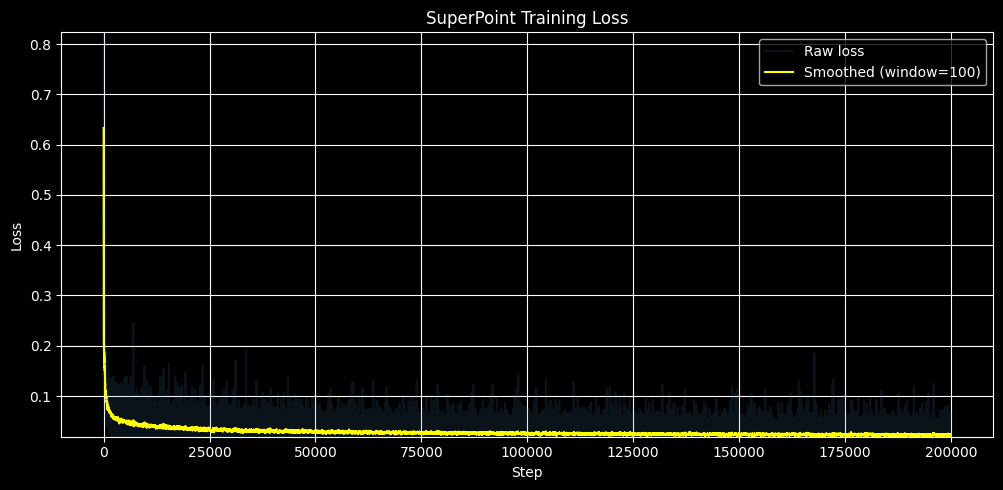

In [149]:
def plot_loss(loss_history, smoothing_window=100):
    loss = np.array(loss_history, dtype=float)
    steps = len(loss)
    loss_x = np.linspace(1, steps, steps)

    if len(loss) >= smoothing_window:
        smoothed = np.convolve(loss, np.ones(smoothing_window) / smoothing_window, mode='valid')
        smooth_x = np.linspace(1, steps, len(smoothed))
    else:
        smoothed = loss
        smooth_x = loss_x

    plt.figure(figsize=(10, 5))
    plt.plot(loss_x, loss, alpha=0.15, color='steelblue', label='Raw loss')
    plt.plot(smooth_x, smoothed, color='yellow', linewidth=1.5, label=f'Smoothed (window={smoothing_window})')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('SuperPoint Training Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

plot_loss(loss_history)

In [16]:
def load_model(path='models/model_final.pth'):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model = SuperPointDetector().to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(
        f'loaded model from {path} (iteration={checkpoint.get("iteration")}, loss={checkpoint.get("loss_history", [0])[-1]:.4f})')
    return model

model = load_model('models/model_final.pth')

loaded model from models/model_final.pth (iteration=200000, loss=0.0678)


#### Results visualization
logits_to_heatmap -> it is used post processing, so the logits are better presneted (visuality) on a heatmap. The heatmap is telling us where on the images we have valuable points

In [15]:
def logits_to_heatmap(logits): # org prediction
    batch_size, _, height_cells, width_cells = logits.shape # (B, 65, H//8, W//8)
    probabilities = F.softmax(logits, dim=1)[:, :-1]  # (B, 64, H//8, W//8)
    probabilities = probabilities.view(batch_size, 8, 8, height_cells, width_cells) # (B, 8, 8, H//8, W//8)
    probabilities = probabilities.permute(0, 3, 1, 4, 2)  # (B, H//8, 8, W//8, 8)
    heatmap = probabilities.reshape(batch_size, 1, height_cells * 8, width_cells * 8) # (B, 1, H, W)

    return heatmap


def get_keypoints_from_heatmap(heatmap, threshold):
    probability_map = heatmap[0, 0].cpu().numpy()  # (1, 1, H, W)
    coordinates_yx = np.argwhere(probability_map > threshold)  # [y, x]
    keypoints_list = [(int(x), int(y)) for y, x in coordinates_yx]
    return keypoints_list, probability_map

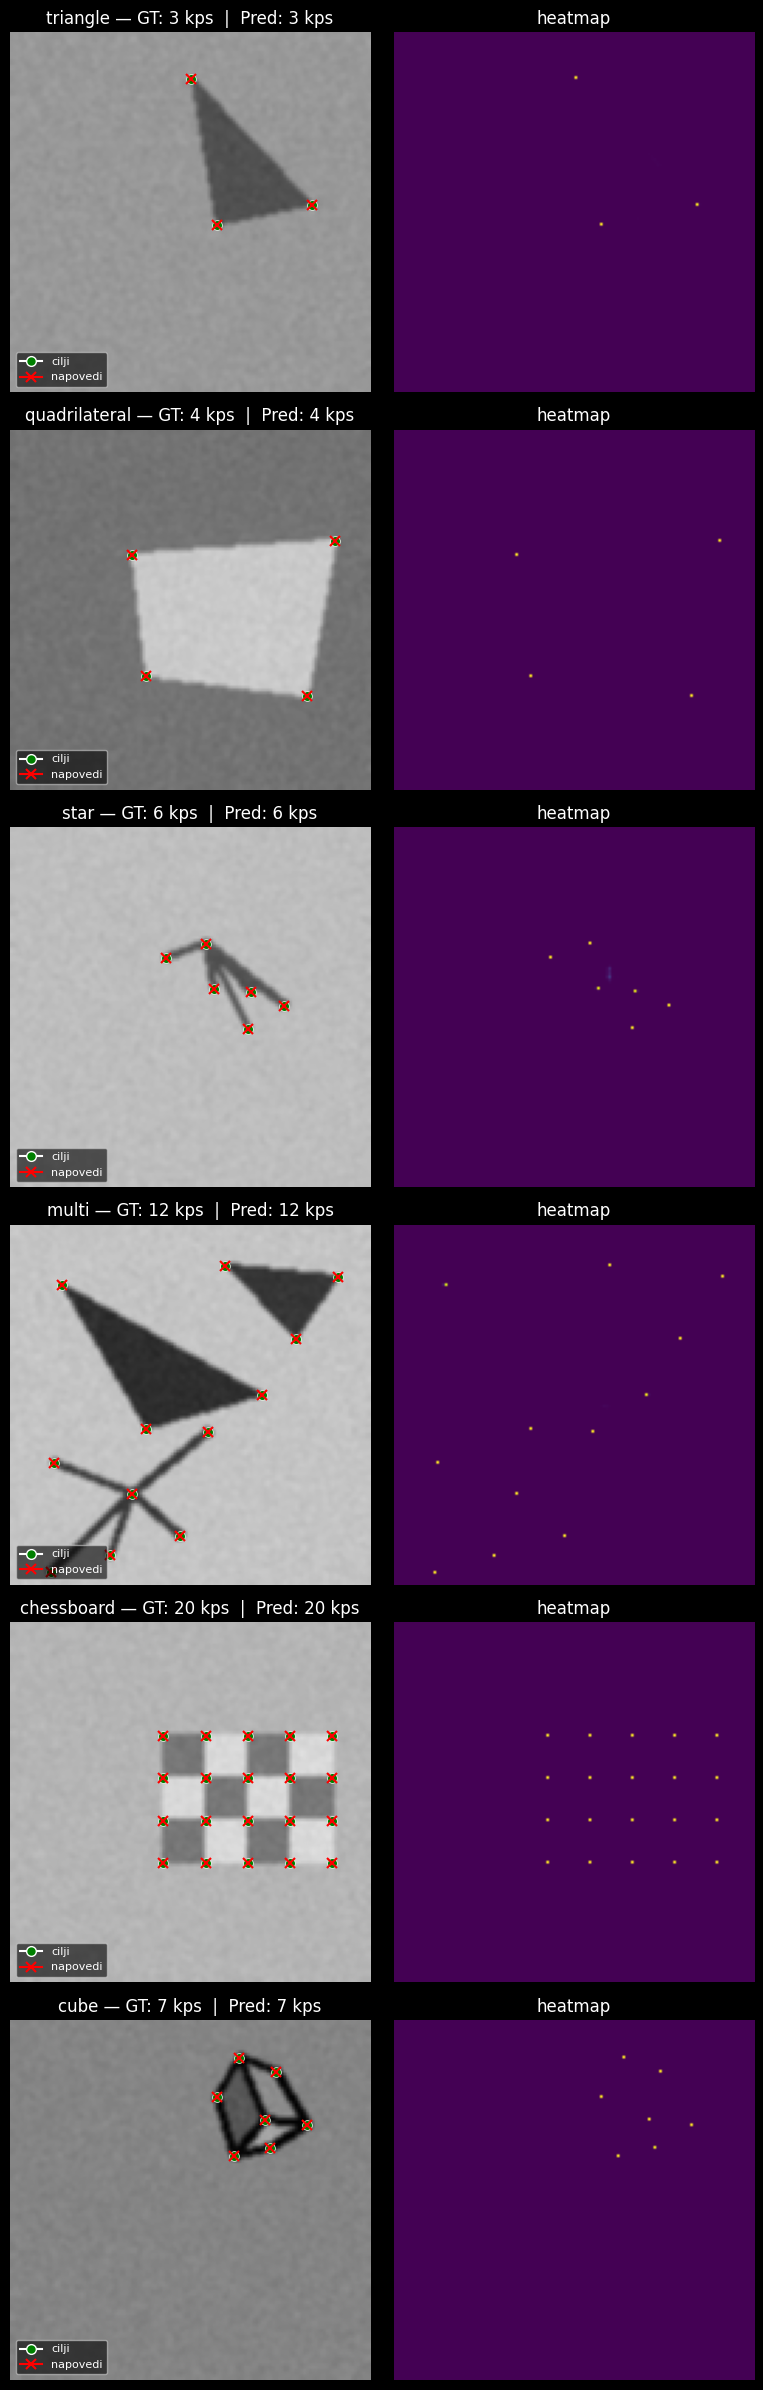

In [143]:
def show_predictions(model, threshold=0.45):
    IMG_W, IMG_H = 128, 128
    samples = [
        ('triangle',       lambda: generate_image_with_shape('triangle', IMG_W, IMG_H)),
        ('quadrilateral',  lambda: generate_image_with_shape('quadrilateral', IMG_W, IMG_H)),
        ('star',           lambda: generate_image_with_shape('star', IMG_W, IMG_H)),
        ('multi',          lambda: generate_image_with_more_shapes(IMG_W, IMG_H, 5)),
        ('chessboard',     lambda: generate_image_with_shape('chessboard', IMG_W, IMG_H)),
        ('cube',           lambda: generate_image_with_shape('cube', IMG_W, IMG_H)),
    ]

    fig, axs = plt.subplots(len(samples), 2, figsize=(8, 4 * len(samples)))

    model.eval()
    with torch.no_grad():
        for row, (shape_name, generate) in enumerate(samples):
            image, gt_keypoints = generate()

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
            image_tensor = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(device)

            pred_keypoints, prob_map = get_keypoints_from_heatmap(
                logits_to_heatmap(model(image_tensor)), threshold
            )

            axs[row, 0].imshow(gray, cmap='gray', vmin=0, vmax=1)
            for x, y in gt_keypoints:
                axs[row, 0].plot(x, y, 'go', ms=7, markerfacecolor='g',
                                 markeredgecolor='white', markeredgewidth=0.5)
            for x, y in pred_keypoints:
                axs[row, 0].plot(x, y, 'rx', ms=7, mew=1.5)
            axs[row, 0].legend(handles=[
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=7, label='cilji'),
                plt.Line2D([0], [0], marker='x', color='r', markersize=7, markeredgewidth=1.5, label='napovedi'),
            ], loc='lower left', fontsize=8, framealpha=0.6)
            axs[row, 0].set_title(f'{shape_name} GT: {len(gt_keypoints)} kps  |  Pred: {len(pred_keypoints)} kps')
            axs[row, 0].axis('off')

            axs[row, 1].imshow(prob_map, cmap='viridis')
            axs[row, 1].set_title('heatmap')
            axs[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


show_predictions(model)

#### Homographic adaptation

In [17]:
def homographic_adaptation(model, image):
    height, width = image.shape
    total_heatmap = np.zeros((height, width), dtype=np.float32) # H W
    total_counts = np.zeros((height, width), dtype=np.float32)

    mask_ones = np.ones((height, width), dtype=np.float32) #white

    with torch.no_grad():
        input_tensor = torch.from_numpy(image).view(1, 1, height, width).to(device)  #  (1, 1, H, W)
        original_prediction = logits_to_heatmap(model(input_tensor))[0, 0].cpu().numpy()  #(H, W)

    total_heatmap += original_prediction
    total_counts += mask_ones

    for _ in range(99):
        H = generate_random_homography(width, height)
        warped_img = cv2.warpPerspective(image, H, (width, height)) #  (1, 1, H, W)

        with torch.no_grad():
            warped_tensor = torch.from_numpy(warped_img).view(1, 1, height, width).to(device)
            warped_heatmap = logits_to_heatmap(model(warped_tensor))[0, 0].cpu().numpy()  #  (H, W)

        H_inv = np.linalg.inv(H)
        heatmap_back = cv2.warpPerspective(warped_heatmap, H_inv, (width, height)) # (H, W)

        pixels_back = cv2.warpPerspective(mask_ones, H_inv, (width, height), flags=cv2.INTER_NEAREST)

        total_heatmap += heatmap_back
        total_counts += pixels_back

    final_heatmap = total_heatmap / np.maximum(total_counts, 1.0) #  (H, W)

    return final_heatmap

#### Demo on real photo

Processing: BSD_dataset\118035.jpg


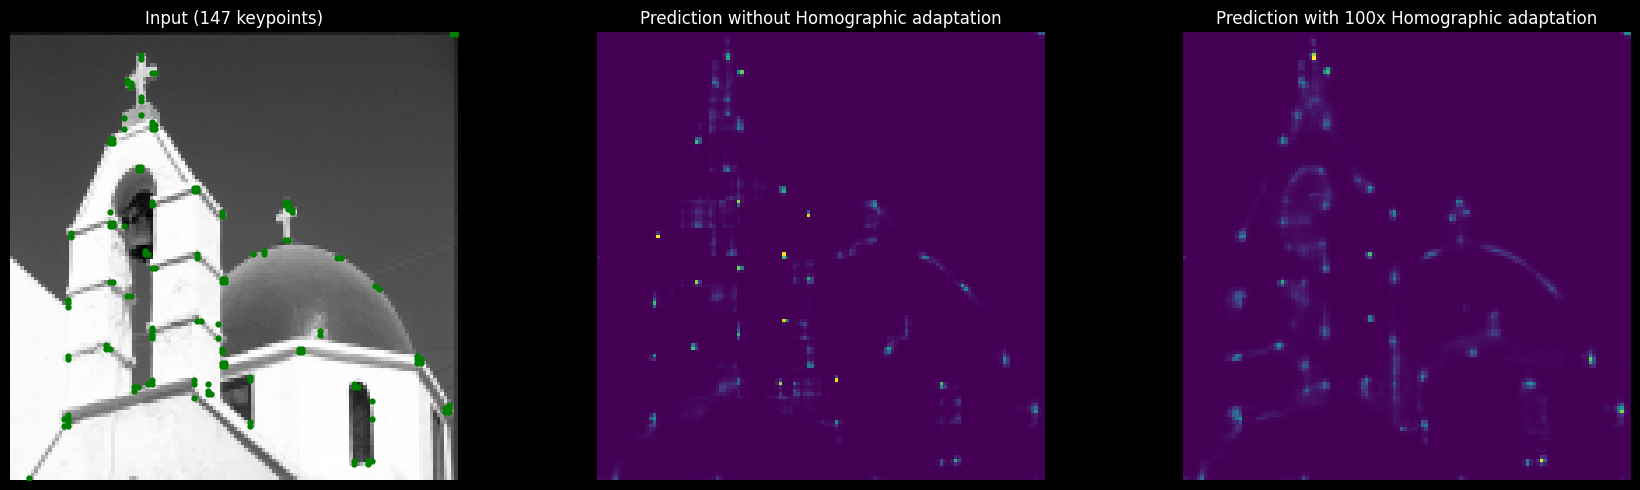

Processing: BSD_dataset\124084.jpg


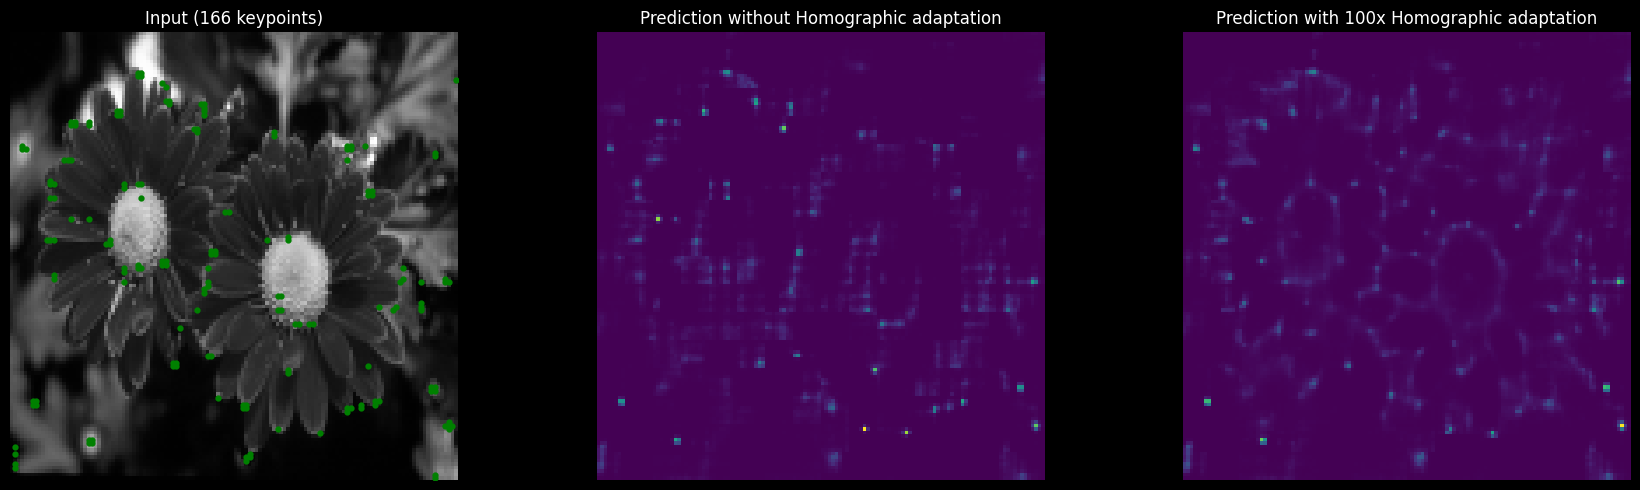

Processing: BSD_dataset\135069.jpg


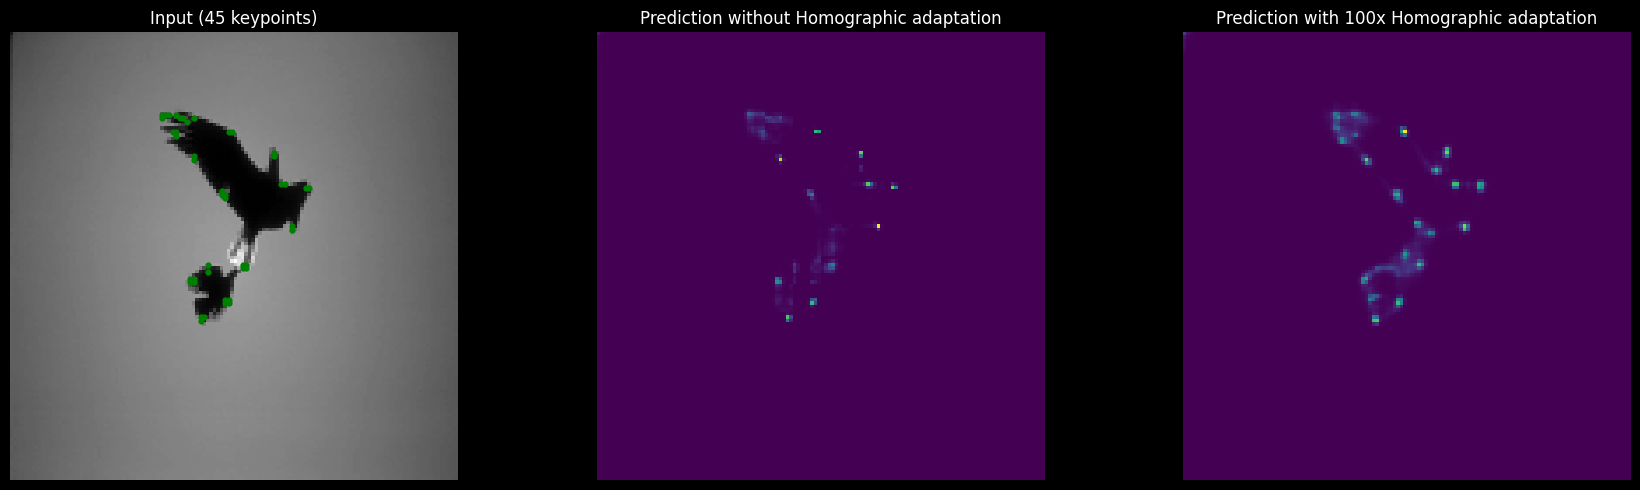

Processing: BSD_dataset\187029.jpg


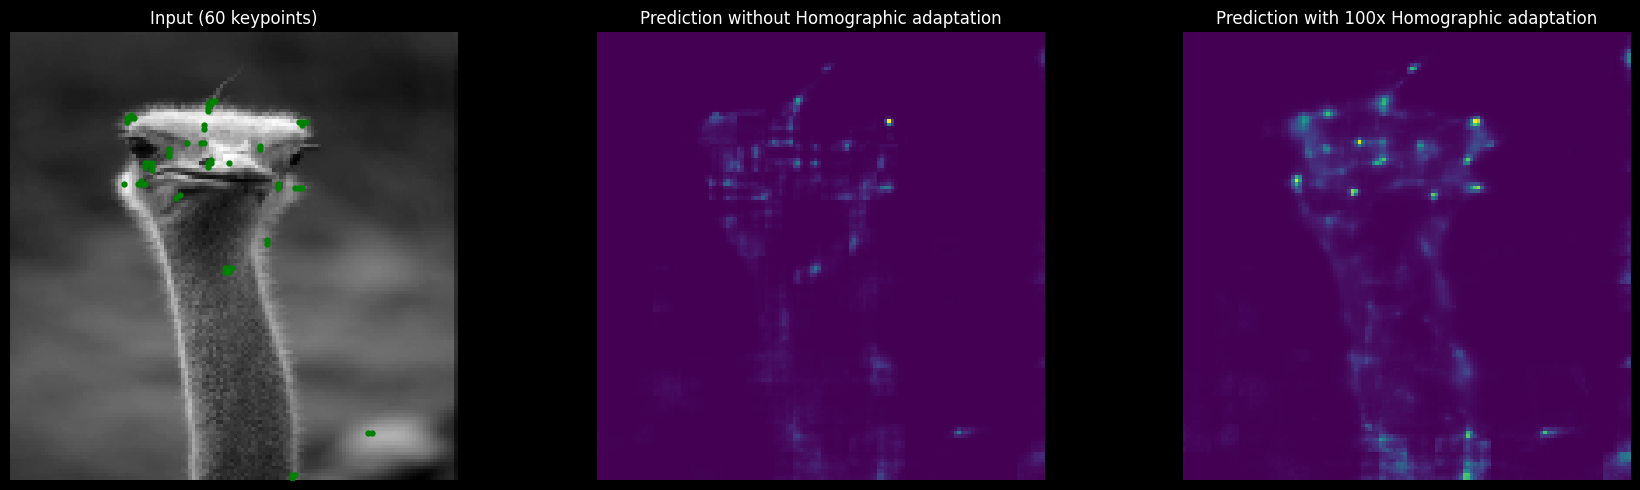

Processing: BSD_dataset\189011.jpg


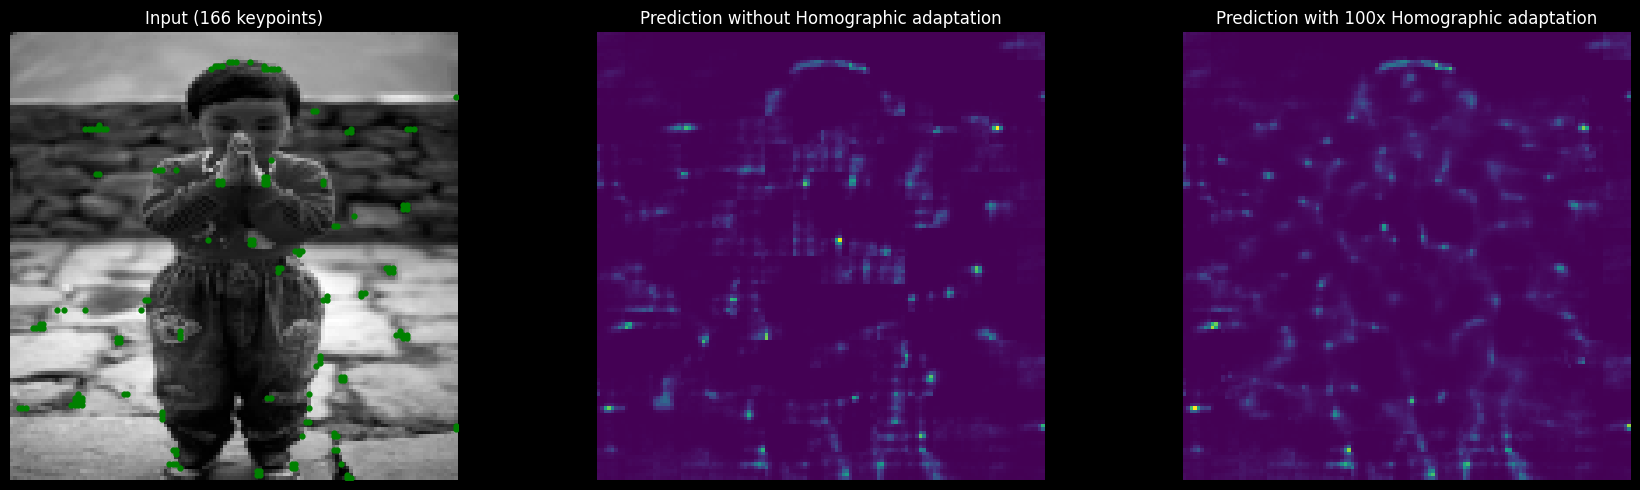

Processing: BSD_dataset\198054.jpg


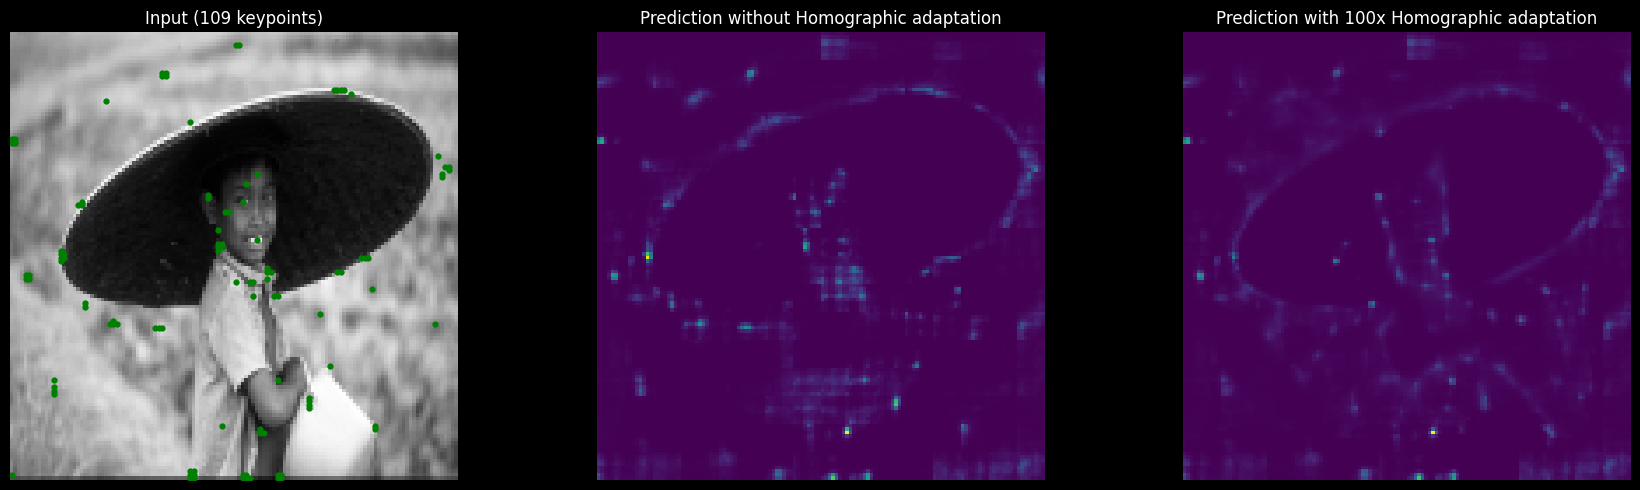

Processing: BSD_dataset\66075.jpg


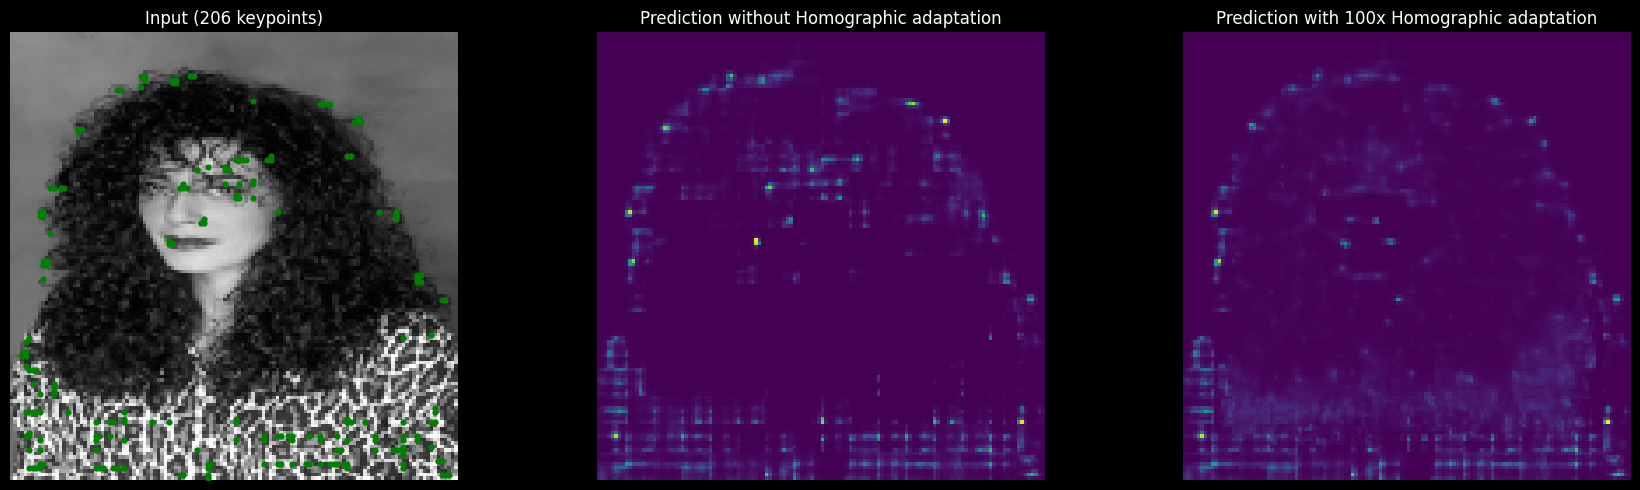

In [25]:
def predict_on_photo(path, model):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(path)
    image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    image_tensor = torch.from_numpy(grayscale).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        heatmap_tensor = logits_to_heatmap(model(image_tensor))

    single_keypoints, single_heatmap = get_keypoints_from_heatmap(heatmap_tensor, threshold=0.05)

    adapted_heatmap = homographic_adaptation(model, grayscale)
    adapted_heatmap_tensor = torch.from_numpy(adapted_heatmap).unsqueeze(0).unsqueeze(0)
    adapted_keypoints, _ = get_keypoints_from_heatmap(adapted_heatmap_tensor, threshold=0.05)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(grayscale, cmap='gray')
    for x, y in single_keypoints:
        axes[0].plot(x, y, 'g.', ms=6, mew=1.5)
    axes[0].set_title(f'Input ({len(single_keypoints)} keypoints)')
    axes[0].axis('off')

    axes[1].imshow(single_heatmap, cmap='viridis')
    axes[1].set_title('Prediction without Homographic adaptation')
    axes[1].axis('off')

    axes[2].imshow(adapted_heatmap, cmap='viridis')
    axes[2].set_title('Prediction with 100x Homographic adaptation')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap


all_photos = sorted(glob.glob('BSD_dataset/**/*.jpg', recursive=True) +
                    glob.glob('BSD_dataset/**/*.png', recursive=True))

for path in all_photos:
    print(f'Processing: {path}')
    predict_on_photo(path, model)